<a href="https://colab.research.google.com/github/FBenita/Clinic_Staffing_DES_GA/blob/main/02_robust_reformulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 2 — The Robust Reformulation

**Companion code for:** *Robust Staffing of Walk-In Clinics under Demand Uncertainty: A Simulation-Optimization Approach with Exact Benchmarking* (Francisco Benita, Tecnológico de Monterrey)

This notebook is self-contained: it redefines the simulation engine from scratch and
does not depend on Notebook 1 having been run first. Running it top to bottom
reproduces every number, table, and figure this paper reports for the **robust**
staffing problem.

The nominal problem (Notebook 1) asks for the cheapest staffing plan that clears a
service-level floor under one expected demand scenario. That is not the same question
as whether the plan holds up if demand runs higher than expected. This notebook asks
the second question directly: a configuration is *robustly feasible* only if it clears
the same service-level floor under **both** of two operating scenarios,

- $\theta_0$ — the nominal, base-case day (mean inter-arrival time 5.0 minutes), and
- $\theta_1$ — a busier day (mean inter-arrival time 4.0 minutes),

and its cost and waiting-time objectives are then evaluated at their **worst case**
across the two scenarios, rather than at either scenario alone. These are the same two
scenarios used throughout the paper; no other scenario or demand level is introduced
here.

Because the underlying decision space is unchanged ($\mathcal{X}=\{1,\dots,5\}^4$,
still only 625 configurations), the same exhaustive-enumeration ground truth used in
Notebook 1 stays available here, now evaluated under two scenarios instead of one,
which is exactly what lets NSGA-II's exactness be checked again on a harder problem,
using the same verifiable-laboratory logic as Notebook 1.

Runtime on a standard Colab CPU runtime: roughly 15–20 minutes (evaluating two
scenarios per configuration, instead of one, is the main driver).

## 0. Google Drive setup

In [ ]:
from google.colab import drive
import os
from pathlib import Path

drive.mount('/content/drive')
base_path = '/content/drive/My Drive/clinic2026'
os.makedirs(os.path.join(base_path, 'figures'), exist_ok=True)
os.makedirs(os.path.join(base_path, 'tables'), exist_ok=True)
os.chdir(base_path)

FIGURES_DIR = Path("figures")
TABLES_DIR = Path("tables")
print("Working directory:", os.getcwd())

Mounted at /content/drive
Working directory: /content/drive/My Drive/clinic2026


## 1. Simulation engine (identical to Notebook 1)

Copied here unchanged so this notebook can be run on its own. See Notebook 1 for the
full explanation of the five-stage queueing model, the cost structure, and why the
service-level floor is enforced as a hard feasibility constraint rather than a soft
penalty.

In [ ]:
import heapq
import itertools
import time as _time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

RESOURCE_COSTS = {"receptionist": 110, "nurse": 160, "doctor": 250, "pharmacy": 130}
RESOURCE_NAMES = ["receptionist", "nurse", "doctor", "pharmacy"]
SIM_TIME = 480.0
N_REPLICATIONS = 30
BOUNDS = [(1, 5)] * 4
MIN_SERVICE_LEVEL = 0.90

WEIGHT_SETS = [
    (0.80, 0.10, 0.10), (0.10, 0.80, 0.10), (0.10, 0.10, 0.80), (0.33, 0.33, 0.33),
    (0.50, 0.50, 0.00), (0.50, 0.00, 0.50), (0.00, 0.50, 0.50), (0.25, 0.25, 0.50),
]

STAGE_ORDER = [
    ("reception1", "receptionist"), ("nurse", "nurse"), ("doctor", "doctor"),
    ("pharmacy", "pharmacy"), ("reception2", "receptionist"),
]

def _draw_service(stage, rng):
    if stage in ("reception1", "reception2"):
        return max(rng.uniform(5, 7), 1e-6)
    if stage == "nurse":
        return max(rng.normal(10, 2), 1e-6)
    if stage == "doctor":
        return max(rng.normal(15, 3), 1e-6)
    if stage == "pharmacy":
        return max(rng.normal(8, 1), 1e-6)
    raise ValueError(stage)

class _Resource:
    __slots__ = ("capacity", "busy", "queue")
    def __init__(self, capacity):
        self.capacity = int(capacity); self.busy = 0; self.queue = []

def simulate_clinic(staffing, arrival_mean=5.0, sim_time=SIM_TIME, rng=None, trace=False):
    if rng is None:
        rng = np.random.default_rng()
    n_rec, n_nur, n_doc, n_pha = staffing
    resources = {"receptionist": _Resource(n_rec), "nurse": _Resource(n_nur),
                 "doctor": _Resource(n_doc), "pharmacy": _Resource(n_pha)}
    arrival_time, total_service_time, next_stage_idx, completion_time = {}, {}, {}, {}
    event_q, counter = [], 0

    def push(t, kind, pid, extra=None):
        nonlocal counter
        counter += 1
        heapq.heappush(event_q, (t, counter, kind, pid, extra))

    res_log = [] if trace else None
    def log_resource(t, name):
        if trace:
            res_log.append((t, name, len(resources[name].queue), resources[name].busy))

    t, pid = 0.0, 0
    while True:
        iat = max(rng.normal(arrival_mean, 1.0), 1e-6)
        t += iat
        if t >= sim_time:
            break
        arrival_time[pid] = t; total_service_time[pid] = 0.0; next_stage_idx[pid] = 0
        push(t, "arrive", pid); pid += 1
    n_generated = pid

    def try_start(res_name, t):
        res = resources[res_name]
        while res.busy < res.capacity and res.queue:
            p = res.queue.pop(0)
            stage_name, _ = STAGE_ORDER[next_stage_idx[p]]
            dur = _draw_service(stage_name, rng)
            total_service_time[p] += dur; res.busy += 1
            push(t + dur, "complete", p, res_name)
        log_resource(t, res_name)

    while event_q:
        t, _, kind, p, extra = heapq.heappop(event_q)
        if t >= sim_time:
            break
        if kind == "arrive":
            stage_name, res_name = STAGE_ORDER[0]
            res = resources[res_name]
            if res.busy < res.capacity:
                dur = _draw_service(stage_name, rng)
                total_service_time[p] += dur; res.busy += 1
                push(t + dur, "complete", p, res_name)
            else:
                res.queue.append(p)
            log_resource(t, res_name)
        elif kind == "complete":
            res_name = extra
            resources[res_name].busy -= 1
            next_stage_idx[p] += 1
            if next_stage_idx[p] >= len(STAGE_ORDER):
                completion_time[p] = t
            else:
                stage_name, next_res_name = STAGE_ORDER[next_stage_idx[p]]
                nxt = resources[next_res_name]
                if nxt.busy < nxt.capacity:
                    dur = _draw_service(stage_name, rng)
                    total_service_time[p] += dur; nxt.busy += 1
                    push(t + dur, "complete", p, next_res_name)
                else:
                    nxt.queue.append(p)
            try_start(res_name, t)

    manpower_cost = sum(RESOURCE_COSTS[r] * staffing[i] for i, r in enumerate(RESOURCE_NAMES))
    finished = list(completion_time.keys())
    patients_served = len(finished)
    if patients_served == 0:
        waiting_cost, wait_times = 0.0, np.array([])
    else:
        wait_times = np.array([(completion_time[p] - arrival_time[p]) - total_service_time[p] for p in finished])
        waiting_cost = float(wait_times.sum() * ((RESOURCE_COSTS["nurse"] / sim_time) * 0.5))

    out = {"waiting_cost": waiting_cost, "manpower_cost": float(manpower_cost),
           "patients_served": patients_served, "n_generated": n_generated,
           "unfinished": n_generated - patients_served, "wait_times": wait_times}
    if trace:
        out["resource_log"] = res_log
        out["arrival_time"] = dict(arrival_time)
        out["completion_time"] = dict(completion_time)
    return out

def run_replications(staffing, n_reps=N_REPLICATIONS, arrival_mean=5.0, sim_time=SIM_TIME):
    wc = np.zeros(n_reps); mc = np.zeros(n_reps); ps = np.zeros(n_reps)
    gen = np.zeros(n_reps); unfinished = np.zeros(n_reps)
    for i in range(n_reps):
        rng = np.random.default_rng(i + 1)
        o = simulate_clinic(staffing, arrival_mean, sim_time, rng)
        wc[i], mc[i], ps[i] = o["waiting_cost"], o["manpower_cost"], o["patients_served"]
        gen[i], unfinished[i] = o["n_generated"], o["unfinished"]
    return {"waiting_cost": wc, "manpower_cost": mc, "patients_served": ps,
            "n_generated": gen, "unfinished": unfinished}

def service_level_of(r):
    return r["patients_served"].mean() / r["n_generated"].mean()

def pareto_dominates(a, b):
    """a dominates b: minimize waiting_cost & manpower_cost, maximize patients_served."""
    better_or_eq = (a["waiting_cost"] <= b["waiting_cost"] and a["manpower_cost"] <= b["manpower_cost"]
                    and a["patients_served"] >= b["patients_served"])
    strictly_better = (a["waiting_cost"] < b["waiting_cost"] or a["manpower_cost"] < b["manpower_cost"]
                        or a["patients_served"] > b["patients_served"])
    return better_or_eq and strictly_better

def mean_utilization(staffing, n_reps=N_REPLICATIONS, arrival_mean=5.0):
    capacities = dict(zip(RESOURCE_NAMES, staffing))
    util_sums = {name: 0.0 for name in RESOURCE_NAMES}
    for i in range(n_reps):
        rng = np.random.default_rng(i + 1)
        out = simulate_clinic(staffing, arrival_mean=arrival_mean, rng=rng, trace=True)
        log = pd.DataFrame(out["resource_log"], columns=["time", "resource", "queue_len", "busy"])
        for name in RESOURCE_NAMES:
            sub = log[log.resource == name].sort_values("time")
            if sub.empty:
                continue
            t = np.concatenate([[0.0], sub["time"].values, [SIM_TIME]])
            busy = np.concatenate([[0], sub["busy"].values, [sub["busy"].values[-1]]])
            dt = np.diff(t)
            util_sums[name] += float(np.sum(busy[:-1] * dt) / (SIM_TIME * capacities[name]))
    return {name: util_sums[name] / n_reps for name in RESOURCE_NAMES}

print("Setup OK.")

Setup OK.


## 2. Two operating scenarios, and the worst-case objectives

$\Theta=\{\theta_0,\theta_1\}$ fixes the scenario set for the whole notebook, nothing
here searches over or adds a third scenario. For a configuration $\mathbf{x}$, running
the engine once under each scenario gives two service levels, $\mathrm{SL}(\mathbf{x};\theta_0)$
and $\mathrm{SL}(\mathbf{x};\theta_1)$; $\mathbf{x}$ is **robustly feasible** only if
both clear `MIN_SERVICE_LEVEL`. Manpower cost does not depend on how demand turns out,
so it needs no scenario treatment. Waiting cost and patients served do: each is
evaluated at its **worst case** across $\Theta$ (the higher of the two waiting costs,
the lower of the two served counts) rather than at either scenario alone, since a
robust plan is judged by how it performs on its worst day, not its average one.

In [ ]:
SCENARIOS = {"theta0": 5.0, "theta1": 4.0}   # mean inter-arrival time, minutes
SCENARIO_LABEL = {"theta0": "nominal (baseline) day", "theta1": "high-demand day"}

def run_robust(staffing, n_reps=N_REPLICATIONS):
    """Evaluate one configuration under both scenarios in Theta and summarize the
    worst-case objectives and robust feasibility used throughout this notebook."""
    r0 = run_replications(staffing, n_reps=n_reps, arrival_mean=SCENARIOS["theta0"])
    r1 = run_replications(staffing, n_reps=n_reps, arrival_mean=SCENARIOS["theta1"])
    sl0, sl1 = service_level_of(r0), service_level_of(r1)
    wait0, wait1 = r0["waiting_cost"].mean(), r1["waiting_cost"].mean()
    served0, served1 = r0["patients_served"].mean(), r1["patients_served"].mean()
    return {
        "manpower_cost": r0["manpower_cost"].mean(),   # deterministic; identical under r1
        "sl0": sl0, "sl1": sl1,
        "wait0": wait0, "wait1": wait1,
        "served0": served0, "served1": served1,
        "waiting_cost_R": max(wait0, wait1),           # worst case: the higher cost
        "patients_served_R": min(served0, served1),    # worst case: the fewer served
        "feasible_R": (sl0 >= MIN_SERVICE_LEVEL) and (sl1 >= MIN_SERVICE_LEVEL),
    }

print("Scenario set Theta =", SCENARIOS)

Scenario set Theta = {'theta0': 5.0, 'theta1': 4.0}


## 3. Recomputing the nominal front

Needed as the reference line for the nominal-vs-robust comparison later in this
notebook (Sections 8–9). Identical to Notebook 1, Section 2.

In [ ]:
print("Recomputing the nominal front (Theta = {theta0} only) ...")
t0 = _time.time()
nominal_rows = []
for combo in itertools.product(range(1, 6), repeat=4):
    r = run_replications(combo, arrival_mean=SCENARIOS["theta0"])
    sl = service_level_of(r)
    nominal_rows.append({
        "Rec": combo[0], "Nur": combo[1], "Doc": combo[2], "Pha": combo[3],
        "waiting_cost": round(r["waiting_cost"].mean(), 2),
        "manpower_cost": round(r["manpower_cost"].mean(), 2),
        "patients_served": round(r["patients_served"].mean(), 2),
        "feasible": sl >= MIN_SERVICE_LEVEL,
    })
nominal_all_df = pd.DataFrame(nominal_rows)
nominal_feasible_df = nominal_all_df[nominal_all_df.feasible].reset_index(drop=True)
nominal_feasible_records = nominal_feasible_df.to_dict("records")
nominal_front = [r for r in nominal_feasible_records
                  if not any(pareto_dominates(o, r) for o in nominal_feasible_records if o is not r)]
nominal_front_df = pd.DataFrame(nominal_front).sort_values("manpower_cost").reset_index(drop=True)
print(f"Done in {_time.time()-t0:.1f}s. Nominal front: {len(nominal_front_df)} solutions "
      f"({len(nominal_feasible_df)}/{len(nominal_all_df)} feasible).")

Recomputing the nominal front (Theta = {theta0} only) ...
Done in 39.3s. Nominal front: 17 solutions (72/625 feasible).


## 4. Exhaustive enumeration: the robust ground truth

Every one of the 625 configurations, now evaluated under **both** scenarios. This
doubles the simulation cost of Notebook 1's enumeration but the search space itself is
unchanged, so it remains exact and exhaustive: the resulting front is the true,
complete robust Pareto front, not an approximation.

In [ ]:
print(f"Enumerating all {5**4} staffing combinations under both scenarios in Theta ...")
t0 = _time.time()
robust_rows = []
for combo in itertools.product(range(1, 6), repeat=4):
    o = run_robust(combo)
    robust_rows.append({
        "Rec": combo[0], "Nur": combo[1], "Doc": combo[2], "Pha": combo[3],
        "waiting_cost": round(o["waiting_cost_R"], 2),
        "manpower_cost": round(o["manpower_cost"], 2),
        "patients_served": round(o["patients_served_R"], 2),
        "sl0": round(100 * o["sl0"], 1), "sl1": round(100 * o["sl1"], 1),
        "feasible": o["feasible_R"],
    })
t1 = _time.time()
enum_runtime = t1 - t0
robust_all_df = pd.DataFrame(robust_rows)
robust_feasible_df = robust_all_df[robust_all_df.feasible].reset_index(drop=True)
print(f"Done in {enum_runtime:.1f}s. Robustly feasible: {len(robust_feasible_df)} of {len(robust_all_df)} "
      f"combinations ({100*len(robust_feasible_df)/len(robust_all_df):.1f}%).")

robust_feasible_records = robust_feasible_df.to_dict("records")
robust_front = [r for r in robust_feasible_records
                 if not any(pareto_dominates(o, r) for o in robust_feasible_records if o is not r)]
robust_front_df = pd.DataFrame(robust_front).sort_values("manpower_cost").reset_index(drop=True)
print(f"True robust Pareto front size: {len(robust_front_df)} non-dominated, robustly feasible solutions.")
print(robust_front_df.to_string(index=False))
robust_front_df.to_csv(TABLES_DIR / "robust_pareto_front.csv", index=False)
robust_all_df.to_csv(TABLES_DIR / "robust_all_625.csv", index=False)

nominal_set = set(zip(nominal_front_df.Rec, nominal_front_df.Nur, nominal_front_df.Doc, nominal_front_df.Pha))
robust_set = set(zip(robust_front_df.Rec, robust_front_df.Nur, robust_front_df.Doc, robust_front_df.Pha))
print()
print(f"Of the {len(nominal_set)} nominal-front configurations, {len(nominal_set & robust_set)} "
      f"reappear unchanged on the robust front; {len(nominal_set - robust_set)} do not survive "
      f"scenario theta1.")

Enumerating all 625 staffing combinations under both scenarios in Theta ...
Done in 75.1s. Robustly feasible: 28 of 625 combinations (4.5%).
True robust Pareto front size: 13 non-dominated, robustly feasible solutions.
 Rec  Nur  Doc  Pha  waiting_cost  manpower_cost  patients_served  sl0  sl1  feasible
   5    3    4    3         61.05         2420.0            86.83 90.6 90.1      True
   4    3    4    4         56.74         2440.0            86.73 90.5 90.1      True
   4    3    5    3         20.49         2560.0            86.73 90.5 90.3      True
   5    3    5    3         16.22         2670.0            86.70 90.5 90.4      True
   4    3    5    4         19.69         2690.0            86.83 90.6 90.6      True
   4    4    5    3         15.11         2720.0            86.90 90.7 90.4      True
   5    3    5    4         13.65         2800.0            86.80 90.6 90.5      True
   5    4    5    3          8.62         2830.0            86.93 90.7 90.5      True
   5   

## 5. Weighted-sum GA on the robust problem

Same method and hyperparameters as Notebook 1 (`real_valued_ga`, 8 fixed weight
vectors, population 50, 15 generations, seed 42), pointed at the worst-case objectives
and robust feasibility defined in Section 2 instead of the single-scenario ones.

In [ ]:
def real_valued_ga(fitness_fn, bounds=BOUNDS, pop_size=50, n_gen=15,
                    pcrossover=0.8, pmutation=0.1, seed=42):
    rng = np.random.default_rng(seed)
    n_var = len(bounds)
    lo = np.array([b[0] for b in bounds], dtype=float)
    hi = np.array([b[1] for b in bounds], dtype=float)
    pop = rng.uniform(lo, hi, size=(pop_size, n_var))
    fitness = np.array([fitness_fn(ind) for ind in pop])
    for _ in range(n_gen):
        best_idx = np.argmax(fitness)
        def tournament():
            idxs = rng.integers(0, pop_size, size=3)
            return pop[idxs[np.argmax(fitness[idxs])]].copy()
        new_pop = np.empty_like(pop)
        new_pop[0] = pop[best_idx]
        i = 1
        while i < pop_size:
            p1, p2 = tournament(), tournament()
            if rng.random() < pcrossover:
                alpha = rng.random(n_var)
                c1 = alpha * p1 + (1 - alpha) * p2
                c2 = alpha * p2 + (1 - alpha) * p1
            else:
                c1, c2 = p1.copy(), p2.copy()
            for child in (c1, c2):
                if i >= pop_size:
                    break
                mask = rng.random(n_var) < pmutation
                if mask.any():
                    child[mask] += rng.normal(0, 0.5, size=mask.sum()) * (hi[mask] - lo[mask])
                new_pop[i] = np.clip(child, lo, hi)
                i += 1
        pop = new_pop
        fitness = np.array([fitness_fn(ind) for ind in pop])
    best_idx = np.argmax(fitness)
    return {"best_x": pop[best_idx].copy(), "best_fitness": fitness[best_idx]}

def make_fitness(w_wait, w_man, w_pat, n_reps=N_REPLICATIONS, min_service_level=MIN_SERVICE_LEVEL):
    def fitness(x):
        staffing = tuple(int(v) for v in np.clip(np.round(x), 1, 5))
        o = run_robust(staffing, n_reps=n_reps)
        min_sl = min(o["sl0"], o["sl1"])
        if min_sl < min_service_level:
            return -1_000_000 + 100_000 * min_sl
        return -(w_wait * o["waiting_cost_R"]) - (w_man * o["manpower_cost"]) + (w_pat * o["patients_served_R"])
    return fitness

print("Running weighted-sum GA on the robust problem (8 weight vectors) ...")
t0 = _time.time()
ga_rows = []
for i, (w_wait, w_man, w_pat) in enumerate(WEIGHT_SETS, start=1):
    res = real_valued_ga(make_fitness(w_wait, w_man, w_pat), seed=42)
    staffing = tuple(int(v) for v in np.clip(np.round(res["best_x"]), 1, 5))
    o = run_robust(staffing)
    if min(o["sl0"], o["sl1"]) >= MIN_SERVICE_LEVEL:
        ga_rows.append({"Rec": staffing[0], "Nur": staffing[1], "Doc": staffing[2], "Pha": staffing[3],
                         "waiting_cost": round(o["waiting_cost_R"], 2),
                         "manpower_cost": round(o["manpower_cost"], 2),
                         "patients_served": round(o["patients_served_R"], 2)})
t1 = _time.time()
ga_runtime = t1 - t0
seen, ga_unique = set(), []
for row in ga_rows:
    key = (row["Rec"], row["Nur"], row["Doc"], row["Pha"])
    if key not in seen:
        seen.add(key); ga_unique.append(row)
ga_front = [r for r in ga_unique if not any(pareto_dominates(o, r) for o in ga_unique if o is not r)]
ga_front_df = pd.DataFrame(ga_front).sort_values("manpower_cost").reset_index(drop=True)
print(f"Weighted-sum GA: {len(ga_front_df)} unique non-dominated solution(s) found in {ga_runtime:.1f}s "
      f"(of {len(robust_front_df)} that truly exist)")
print(ga_front_df.to_string(index=False))

Running weighted-sum GA on the robust problem (8 weight vectors) ...
Weighted-sum GA: 3 unique non-dominated solution(s) found in 1009.0s (of 13 that truly exist)
 Rec  Nur  Doc  Pha  waiting_cost  manpower_cost  patients_served
   5    3    4    3         61.05         2420.0            86.83
   4    3    5    3         20.49         2560.0            86.73
   5    5    5    5          4.59         3250.0            86.93


## 6. NSGA-II on the robust problem

Same implementation as Notebook 1 (fast non-dominated sorting, crowding distance,
Deb's constrained-domination rule), same hyperparameters (population 60, 40
generations, seed 42), now searching the worst-case objective space defined in
Section 2.

In [ ]:
def evaluate_ind(staffing, n_reps=N_REPLICATIONS):
    o = run_robust(staffing, n_reps=n_reps)
    min_sl = min(o["sl0"], o["sl1"])
    cv = max(0.0, MIN_SERVICE_LEVEL - min_sl)
    obj = np.array([o["waiting_cost_R"], o["manpower_cost"], -o["patients_served_R"]])
    return obj, cv, min_sl

def constrained_dominates(obj_a, cv_a, obj_b, cv_b):
    a_feas, b_feas = cv_a <= 0, cv_b <= 0
    if a_feas and not b_feas:
        return True
    if not a_feas and b_feas:
        return False
    if not a_feas and not b_feas:
        return cv_a < cv_b
    return np.all(obj_a <= obj_b) and np.any(obj_a < obj_b)

def fast_nondominated_sort(objs, cvs):
    n = len(objs)
    S = [[] for _ in range(n)]
    dom_count = np.zeros(n, dtype=int)
    fronts = [[]]
    for p in range(n):
        for q in range(n):
            if p == q:
                continue
            if constrained_dominates(objs[p], cvs[p], objs[q], cvs[q]):
                S[p].append(q)
            elif constrained_dominates(objs[q], cvs[q], objs[p], cvs[p]):
                dom_count[p] += 1
        if dom_count[p] == 0:
            fronts[0].append(p)
    i = 0
    while fronts[i]:
        nxt = []
        for p in fronts[i]:
            for q in S[p]:
                dom_count[q] -= 1
                if dom_count[q] == 0:
                    nxt.append(q)
        i += 1
        fronts.append(nxt)
    fronts.pop()
    return fronts

def crowding_distance(front_idx, objs):
    n = len(front_idx)
    dist = {idx: 0.0 for idx in front_idx}
    if n <= 2:
        return {idx: np.inf for idx in front_idx}
    for m in range(objs.shape[1]):
        vals = sorted([(objs[idx, m], idx) for idx in front_idx])
        dist[vals[0][1]] = np.inf
        dist[vals[-1][1]] = np.inf
        rng = vals[-1][0] - vals[0][0]
        if rng == 0:
            continue
        for k in range(1, n - 1):
            dist[vals[k][1]] += (vals[k + 1][0] - vals[k - 1][0]) / rng
    return dist

def nsga2(pop_size=60, n_gen=40, pcrossover=0.9, pmutation=0.2, seed=42, n_reps=N_REPLICATIONS,
          log_history=False):
    rng = np.random.default_rng(seed)
    lo = np.array([b[0] for b in BOUNDS], dtype=float)
    hi = np.array([b[1] for b in BOUNDS], dtype=float)
    n_var = len(BOUNDS)
    history = []

    def rounded(x):
        return tuple(int(v) for v in np.clip(np.round(x), 1, 5))

    def eval_pop(pop):
        objs, cvs, sls = [], [], []
        for ind in pop:
            o, cv, sl = evaluate_ind(rounded(ind), n_reps=n_reps)
            objs.append(o); cvs.append(cv); sls.append(sl)
        return np.array(objs), np.array(cvs), np.array(sls)

    def tournament(rank, crowd):
        idxs = rng.integers(0, len(rank), size=2)
        best = idxs[0]
        for idx in idxs[1:]:
            if (rank[idx] < rank[best]) or (rank[idx] == rank[best] and crowd[idx] > crowd[best]):
                best = idx
        return best

    pop = rng.uniform(lo, hi, size=(pop_size, n_var))
    objs, cvs, sls = eval_pop(pop)

    for gen in range(n_gen):
        fronts = fast_nondominated_sort(objs, cvs)
        rank = np.zeros(len(pop), dtype=int)
        crowd = np.zeros(len(pop))
        for r_i, front in enumerate(fronts):
            d = crowding_distance(front, objs)
            for idx in front:
                rank[idx] = r_i
                crowd[idx] = d[idx]

        if log_history:
            feas_mask = cvs <= 0
            n_feas = int(feas_mask.sum())
            n_feas_nd = int(sum(1 for idx in fronts[0] if cvs[idx] <= 0))
            best_cost = float(objs[feas_mask, 1].min()) if n_feas > 0 else np.nan
            best_served = float(-objs[feas_mask, 2].max()) if n_feas > 0 else np.nan
            history.append({"generation": gen, "n_feasible": n_feas, "n_feasible_nondominated": n_feas_nd,
                             "best_manpower_cost": best_cost, "best_patients_served_R": best_served})

        offspring = np.empty_like(pop)
        i = 0
        while i < pop_size:
            p1, p2 = pop[tournament(rank, crowd)], pop[tournament(rank, crowd)]
            if rng.random() < pcrossover:
                alpha = rng.random(n_var)
                c1 = alpha * p1 + (1 - alpha) * p2
                c2 = alpha * p2 + (1 - alpha) * p1
            else:
                c1, c2 = p1.copy(), p2.copy()
            for child in (c1, c2):
                if i >= pop_size:
                    break
                mask = rng.random(n_var) < pmutation
                if mask.any():
                    child[mask] += rng.normal(0, 0.5, size=mask.sum()) * (hi[mask] - lo[mask])
                offspring[i] = np.clip(child, lo, hi)
                i += 1

        off_objs, off_cvs, off_sls = eval_pop(offspring)
        comb_pop = np.vstack([pop, offspring])
        comb_objs = np.vstack([objs, off_objs])
        comb_cvs = np.concatenate([cvs, off_cvs])
        comb_sls = np.concatenate([sls, off_sls])

        comb_fronts = fast_nondominated_sort(comb_objs, comb_cvs)
        new_idx = []
        for front in comb_fronts:
            if len(new_idx) + len(front) <= pop_size:
                new_idx.extend(front)
            else:
                d = crowding_distance(front, comb_objs)
                new_idx.extend(sorted(front, key=lambda idx: -d[idx])[:pop_size - len(new_idx)])
                break
        pop, objs, cvs, sls = comb_pop[new_idx], comb_objs[new_idx], comb_cvs[new_idx], comb_sls[new_idx]

    fronts = fast_nondominated_sort(objs, cvs)
    rows = []
    for idx in fronts[0]:
        if cvs[idx] <= 0:
            staffing = rounded(pop[idx])
            rows.append({"Rec": staffing[0], "Nur": staffing[1], "Doc": staffing[2], "Pha": staffing[3],
                         "waiting_cost": round(objs[idx, 0], 2), "manpower_cost": round(objs[idx, 1], 2),
                         "patients_served": round(-objs[idx, 2], 2)})
    if log_history:
        return rows, history
    return rows

print("Running NSGA-II on the robust problem (population 60, 40 generations) ...")
t0 = _time.time()
nsga2_rows = nsga2()
t1 = _time.time()
nsga2_runtime = t1 - t0
seen, nsga2_unique = set(), []
for row in nsga2_rows:
    key = (row["Rec"], row["Nur"], row["Doc"], row["Pha"])
    if key not in seen:
        seen.add(key); nsga2_unique.append(row)
nsga2_front_df = pd.DataFrame(nsga2_unique).sort_values("manpower_cost").reset_index(drop=True)
print(f"NSGA-II: {len(nsga2_front_df)} unique non-dominated solution(s) found in {nsga2_runtime:.1f}s "
      f"(of {len(robust_front_df)} that truly exist)")
print(nsga2_front_df.to_string(index=False))

nsga2_set = set(zip(nsga2_front_df.Rec, nsga2_front_df.Nur, nsga2_front_df.Doc, nsga2_front_df.Pha))
print(f"Validation: NSGA-II found {len(nsga2_set & robust_set)}/{len(robust_set)} of the true robust front, "
      f"and {len(nsga2_set - robust_set)} point(s) not on the true front (should be 0).")

Running NSGA-II on the robust problem (population 60, 40 generations) ...
NSGA-II: 13 unique non-dominated solution(s) found in 397.9s (of 13 that truly exist)
 Rec  Nur  Doc  Pha  waiting_cost  manpower_cost  patients_served
   5    3    4    3         61.05         2420.0            86.83
   4    3    4    4         56.74         2440.0            86.73
   4    3    5    3         20.49         2560.0            86.73
   5    3    5    3         16.22         2670.0            86.70
   4    3    5    4         19.69         2690.0            86.83
   4    4    5    3         15.11         2720.0            86.90
   5    3    5    4         13.65         2800.0            86.80
   5    4    5    3          8.62         2830.0            86.93
   5    4    5    4          4.87         2960.0            86.90
   5    5    5    3          7.95         2990.0            86.93
   5    4    5    5          4.84         3090.0            86.93
   5    5    5    4          4.75         3120.0

## 7. Greedy bottleneck heuristic on the robust problem

Same rule as Notebook 1 (repeatedly staff the current bottleneck) but the bottleneck
is now identified from utilization under $\theta_1$, the busier scenario, since that is
the scenario that actually binds robust feasibility in this instance (Section 4
established that theta1 is what a nominally cheap plan fails to survive).

In [ ]:
def greedy_bottleneck_heuristic(start=(1, 1, 1, 1), max_steps=16, n_reps=N_REPLICATIONS):
    staffing = list(start)
    trajectory = []
    for step in range(max_steps):
        o = run_robust(tuple(staffing), n_reps=n_reps)
        min_sl = min(o["sl0"], o["sl1"])
        row = {"step": step, "Rec": staffing[0], "Nur": staffing[1], "Doc": staffing[2], "Pha": staffing[3],
               "waiting_cost": round(o["waiting_cost_R"], 2),
               "manpower_cost": round(o["manpower_cost"], 2),
               "patients_served": round(o["patients_served_R"], 2),
               "min_service_level": round(100 * min_sl, 1)}
        trajectory.append(row)
        print(f"  step {step}: ({staffing[0]},{staffing[1]},{staffing[2]},{staffing[3]})  "
              f"min(SL0,SL1)={100*min_sl:.1f}%  manpower=${row['manpower_cost']:.0f}  "
              f"wait_R=${row['waiting_cost']:.2f}")
        if min_sl >= MIN_SERVICE_LEVEL:
            print(f"  -> robustly feasible after {step} increment(s)")
            break
        util = mean_utilization(tuple(staffing), n_reps=n_reps, arrival_mean=SCENARIOS["theta1"])
        candidates = [(name, u) for name, u in util.items() if staffing[RESOURCE_NAMES.index(name)] < 5]
        if not candidates:
            print("  -> all resources maxed out; stopping")
            break
        bottleneck = max(candidates, key=lambda kv: kv[1])[0]
        staffing[RESOURCE_NAMES.index(bottleneck)] += 1
    return trajectory

print("Running greedy bottleneck heuristic on the robust problem (starting from (1,1,1,1)) ...")
t0 = _time.time()
heuristic_traj = greedy_bottleneck_heuristic()
t1 = _time.time()
heuristic_runtime = t1 - t0
heuristic_final = heuristic_traj[-1]
heuristic_df = pd.DataFrame([{"Rec": heuristic_final["Rec"], "Nur": heuristic_final["Nur"],
                               "Doc": heuristic_final["Doc"], "Pha": heuristic_final["Pha"],
                               "waiting_cost": heuristic_final["waiting_cost"],
                               "manpower_cost": heuristic_final["manpower_cost"],
                               "patients_served": heuristic_final["patients_served"]}])
print(f"Greedy heuristic: 1 solution, found in {heuristic_runtime:.1f}s after {len(heuristic_traj)-1} increments")
print(heuristic_df.to_string(index=False))
is_on_true_front = tuple(heuristic_final[k] for k in ["Rec", "Nur", "Doc", "Pha"]) in robust_set
print(f"Is the heuristic solution on the true robust Pareto front? {is_on_true_front}")

Running greedy bottleneck heuristic on the robust problem (starting from (1,1,1,1)) ...
  step 0: (1,1,1,1)  min(SL0,SL1)=12.3%  manpower=$650  wait_R=$515.49
  step 1: (2,1,1,1)  min(SL0,SL1)=24.5%  manpower=$760  wait_R=$757.95
  step 2: (2,2,1,1)  min(SL0,SL1)=24.6%  manpower=$920  wait_R=$765.34
  step 3: (2,3,1,1)  min(SL0,SL1)=24.4%  manpower=$1080  wait_R=$760.17
  step 4: (2,3,2,1)  min(SL0,SL1)=39.8%  manpower=$1330  wait_R=$965.16
  step 5: (3,3,2,1)  min(SL0,SL1)=45.1%  manpower=$1440  wait_R=$978.75
  step 6: (3,3,3,1)  min(SL0,SL1)=45.5%  manpower=$1690  wait_R=$973.47
  step 7: (3,3,4,1)  min(SL0,SL1)=45.6%  manpower=$1940  wait_R=$973.24
  step 8: (3,3,4,2)  min(SL0,SL1)=86.5%  manpower=$2070  wait_R=$225.30
  step 9: (4,3,4,2)  min(SL0,SL1)=87.8%  manpower=$2180  wait_R=$164.82
  step 10: (4,3,4,3)  min(SL0,SL1)=89.9%  manpower=$2310  wait_R=$68.45
  step 11: (4,3,5,3)  min(SL0,SL1)=90.3%  manpower=$2560  wait_R=$20.49
  -> robustly feasible after 11 increment(s)
Greedy

## 8. Method comparison summary and LaTeX tables

In [ ]:
comparison_df = pd.DataFrame([
    {"Method": "Exhaustive enumeration", "Solutions found": len(robust_front_df),
     "Notes": f"Ground truth -- evaluates all 625 combinations under both scenarios in Theta in {enum_runtime:.0f}s"},
    {"Method": "Weighted-sum GA (8 weight vectors)", "Solutions found": len(ga_front_df),
     "Notes": f"Found {len(ga_front_df)}/{len(robust_front_df)} true robust-front points in {ga_runtime:.0f}s"},
    {"Method": "NSGA-II (Deb et al., 2002)", "Solutions found": len(nsga2_front_df),
     "Notes": f"Found {len(nsga2_set & robust_set)}/{len(robust_front_df)} true robust-front points in {nsga2_runtime:.0f}s"},
    {"Method": "Greedy bottleneck heuristic", "Solutions found": 1,
     "Notes": f"1 point in {heuristic_runtime:.0f}s; {'on' if is_on_true_front else 'off'} the true robust front"},
])
print("=" * 70)
print("METHOD COMPARISON -- ROBUST PROBLEM")
print("=" * 70)
print(comparison_df.to_string(index=False))
comparison_df.to_csv(TABLES_DIR / "method_comparison_robust.csv", index=False)

def robust_front_to_latex(df):
    labels = [chr(ord("A") + i) if i < 26 else f"A{i-25}" for i in range(len(df))]
    lines = [r"\begin{table}[htbp]", r"\centering", r"\begin{adjustbox}{max width=\textwidth}",
             r"\begin{tabular}{|l|c|c|c|c|c|c|c|c|c|}", r"\hline",
             r"\textbf{Sol.} & \textbf{Rec} & \textbf{Nur} & \textbf{Doc} & \textbf{Pha} & "
             r"\textbf{Manpower (\$)} & \textbf{Wait$^R$ (\$)} & \textbf{Served$^R$} & "
             r"\textbf{SL($\theta_0$)} & \textbf{SL($\theta_1$)} \\", r"\hline"]
    # df (robust_front_df) already carries sl0/sl1 -- it is a filtered view of
    # robust_all_df, so no merge is needed (an earlier version merged here and
    # collided on the sl0/sl1 column names, which pandas silently resolves by
    # suffixing them to sl0_x/sl0_y, breaking the row['sl0'] lookup below).
    for lab, (_, row) in zip(labels, df.iterrows()):
        lines.append(f"{lab} & {int(row['Rec'])} & {int(row['Nur'])} & {int(row['Doc'])} & {int(row['Pha'])} & "
                      f"{row['manpower_cost']:.0f} & {row['waiting_cost']:.2f} & {row['patients_served']:.2f} & "
                      f"{row['sl0']:.1f}\\% & {row['sl1']:.1f}\\% \\\\")
    lines += [r"\hline", r"\end{tabular}", r"\end{adjustbox}",
              r"\caption{Complete robust Pareto front from exhaustive enumeration "
              r"($\Theta=\{\theta_0,\theta_1\}$, base and high-demand scenarios; worst-case objectives; "
              f"averaged over {N_REPLICATIONS}" r" replications per scenario).}",
              r"\label{tab:robust_pareto_front}", r"\end{table}"]
    return "\n".join(lines)

def comparison_to_latex(df, n_true, label):
    lines = [r"\begin{table}[htbp]", r"\centering", r"\begin{adjustbox}{max width=\textwidth}",
             r"\begin{tabular}{|l|c|p{8cm}|}", r"\hline",
             r"\textbf{Method} & \textbf{Non-dominated solutions found} & \textbf{Notes} \\", r"\hline"]
    for _, row in df.iterrows():
        lines.append(f"{row['Method']} & {row['Solutions found']} & {row['Notes']} \\\\")
    lines += [r"\hline", r"\end{tabular}", r"\end{adjustbox}",
              r"\caption{Benchmarking summary on the robust problem: solutions recovered by each "
              f"method, out of {n_true}" r" that truly exist on the robust Pareto front "
              r"$\mathrm{PF}^R(\Theta)$.}",
              f"\\label{{{label}}}", r"\end{table}"]
    return "\n".join(lines)

robust_tex = robust_front_to_latex(robust_front_df)
comparison_tex = comparison_to_latex(comparison_df, len(robust_front_df), "tab:method_comparison_robust")
(TABLES_DIR / "robust_pareto_front.tex").write_text(robust_tex)
(TABLES_DIR / "method_comparison_robust.tex").write_text(comparison_tex)
print("Saved:", TABLES_DIR / "robust_pareto_front.tex")
print("Saved:", TABLES_DIR / "method_comparison_robust.tex")

METHOD COMPARISON -- ROBUST PROBLEM
                            Method  Solutions found                                                                               Notes
            Exhaustive enumeration               13 Ground truth -- evaluates all 625 combinations under both scenarios in Theta in 75s
Weighted-sum GA (8 weight vectors)                3                                        Found 3/13 true robust-front points in 1009s
        NSGA-II (Deb et al., 2002)               13                                        Found 13/13 true robust-front points in 398s
       Greedy bottleneck heuristic                1                                             1 point in 3s; on the true robust front
Saved: tables/robust_pareto_front.tex
Saved: tables/method_comparison_robust.tex


## 9. Figure: nominal vs. robust

Left panel: which of the nominal-front configurations remain feasible once both
scenarios must be cleared. Right panel: the nominal and robust fronts overlaid, making
the cost of robustness visible directly as an outward shift.

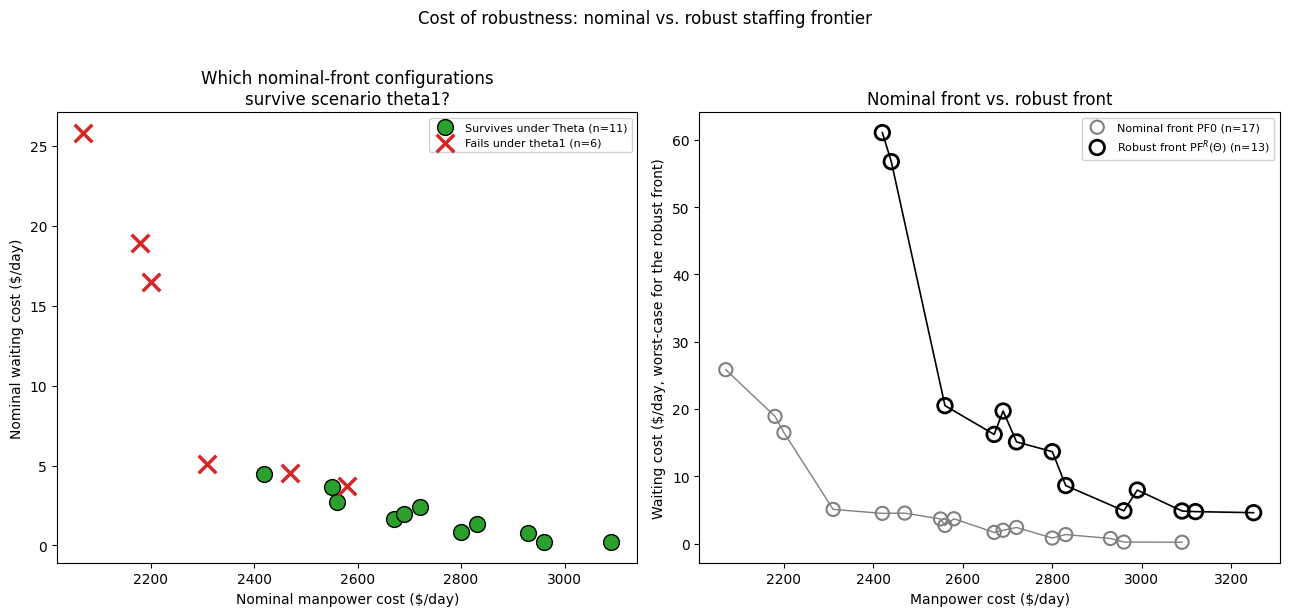

Saved: figures/robust_vs_nominal_front.png


In [ ]:
FIGURE_DPI = 300
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6))

nominal_front_checked = nominal_front_df.merge(
    robust_all_df[["Rec", "Nur", "Doc", "Pha", "feasible"]].rename(columns={"feasible": "robust_feasible"}),
    on=["Rec", "Nur", "Doc", "Pha"], how="left")
survives = nominal_front_checked[nominal_front_checked.robust_feasible]
fails = nominal_front_checked[~nominal_front_checked.robust_feasible]

ax1.scatter(survives.manpower_cost, survives.waiting_cost, s=130, marker="o", color="tab:green",
            edgecolors="black", linewidths=1, zorder=3,
            label=f"Survives under Theta (n={len(survives)})")
ax1.scatter(fails.manpower_cost, fails.waiting_cost, s=160, marker="x", color="tab:red",
            linewidths=2.5, zorder=4, label=f"Fails under theta1 (n={len(fails)})")
ax1.set_xlabel("Nominal manpower cost ($/day)")
ax1.set_ylabel("Nominal waiting cost ($/day)")
ax1.set_title("Which nominal-front configurations\nsurvive scenario theta1?")
ax1.legend(loc="upper right", fontsize=8, framealpha=0.9)

ax2.plot(nominal_front_df.manpower_cost, nominal_front_df.waiting_cost, "-", color="gray",
         linewidth=1, zorder=1)
ax2.scatter(nominal_front_df.manpower_cost, nominal_front_df.waiting_cost, s=90, marker="o",
            facecolors="none", edgecolors="gray", linewidths=1.5, zorder=2,
            label=f"Nominal front PF0 (n={len(nominal_front_df)})")
ax2.plot(robust_front_df.manpower_cost, robust_front_df.waiting_cost, "-", color="black",
         linewidth=1.2, zorder=3)
ax2.scatter(robust_front_df.manpower_cost, robust_front_df.waiting_cost, s=110, marker="o",
            facecolors="none", edgecolors="black", linewidths=2, zorder=4,
            label=f"Robust front PF$^R(\\Theta)$ (n={len(robust_front_df)})")
ax2.set_xlabel("Manpower cost ($/day)")
ax2.set_ylabel("Waiting cost ($/day, worst-case for the robust front)")
ax2.set_title("Nominal front vs. robust front")
ax2.legend(loc="upper right", fontsize=8, framealpha=0.9)

fig.suptitle("Cost of robustness: nominal vs. robust staffing frontier", y=1.02)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "robust_vs_nominal_front.png", dpi=FIGURE_DPI, bbox_inches="tight")
plt.show()
print("Saved:", FIGURES_DIR / "robust_vs_nominal_front.png")

## 10. Summary

In [ ]:
cheapest_nominal = nominal_front_df.iloc[0]
cheapest_robust = robust_front_df.iloc[0]
premium = cheapest_robust.manpower_cost - cheapest_nominal.manpower_cost
print(f"Robust enumeration: {len(robust_feasible_df)}/625 feasible "
      f"({100*len(robust_feasible_df)/625:.1f}%), true robust front = {len(robust_front_df)} solutions, "
      f"runtime {enum_runtime:.1f}s")
print(f"Weighted-sum GA: {len(ga_front_df)} solutions found, runtime {ga_runtime:.1f}s")
print(f"NSGA-II: {len(nsga2_front_df)} solutions found ({len(nsga2_set & robust_set)}/{len(robust_set)} "
      f"match true front), runtime {nsga2_runtime:.1f}s")
print(f"Greedy heuristic: 1 solution ({'on' if is_on_true_front else 'off'} true front), "
      f"runtime {heuristic_runtime:.1f}s")
print()
print(f"Cheapest nominal-feasible configuration: {tuple(int(cheapest_nominal[k]) for k in ['Rec','Nur','Doc','Pha'])}, "
      f"${cheapest_nominal.manpower_cost:.0f}")
print(f"Cheapest robust-feasible configuration: {tuple(int(cheapest_robust[k]) for k in ['Rec','Nur','Doc','Pha'])}, "
      f"${cheapest_robust.manpower_cost:.0f}")
print(f"Cost of robustness at the cheap end: ${premium:.0f} "
      f"({100*premium/cheapest_nominal.manpower_cost:.1f}%)")
print()
print(comparison_df.to_string(index=False))

Robust enumeration: 28/625 feasible (4.5%), true robust front = 13 solutions, runtime 75.1s
Weighted-sum GA: 3 solutions found, runtime 1009.0s
NSGA-II: 13 solutions found (13/13 match true front), runtime 397.9s
Greedy heuristic: 1 solution (on true front), runtime 3.3s

Cheapest nominal-feasible configuration: (3, 3, 4, 2), $2070
Cheapest robust-feasible configuration: (5, 3, 4, 3), $2420
Cost of robustness at the cheap end: $350 (16.9%)

                            Method  Solutions found                                                                               Notes
            Exhaustive enumeration               13 Ground truth -- evaluates all 625 combinations under both scenarios in Theta in 75s
Weighted-sum GA (8 weight vectors)                3                                        Found 3/13 true robust-front points in 1009s
        NSGA-II (Deb et al., 2002)               13                                        Found 13/13 true robust-front points in 398s
       Gree